# 1. Import Libraries

In [55]:
!pip install transformers torch nltk


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


# 2. Import Pipeline

In [56]:
from transformers import pipeline

pretrained_name = "w11wo/indonesian-roberta-base-sentiment-classifier"

classifier = pipeline(
    "sentiment-analysis",
    model=pretrained_name,
    tokenizer=pretrained_name,
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6458.41it/s]


# 3. Try Model

In [57]:
text = "Ekonomi Indonesia sedang tumbuh dengan baik"
print(classifier(text))

text = "Ekonomi Indonesia sedang tumbuh dengan jelek"
print(classifier(text))

[{'label': 'positive', 'score': 0.9899829626083374}]
[{'label': 'negative', 'score': 0.9991164803504944}]


# 4. Import Data

In [66]:
import pandas as pd

df = pd.read_csv("../Dataset/dataset_preprocessed.csv")
df

,date,link,title,konten,konten_length,konten_preprocessed
0,2025-01-21 8:00,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",8326,indonesia amerika serikat resmi milik presiden...
1,2025-01-21 8:00,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",2925,indonesia nilai tukar rupiah dolar amerika ser...
2,2025-01-22 8:00,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",13102,indonesia pasar uang indonesia kuat lantik don...
3,2025-03-04 8:00,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",5158,indonesia indeks harga saham gabung ihsg ambru...
4,2025-03-19 7:00,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,4767,hargabitcoin btc lewat angka tinggi kisara pic...
...,...,...,...,...,...,...
980,2025-06-19 7:00,https://voi.id/teknologi/489452/produsen-mesin...,Produsen Mesin Bitcoin China Pindahkan Produks...,JAKARTA - Tiga produsen mesin penambang bitcoi...,3756,produsen mesin tambang bitcoin besar dunia chi...
981,2025-06-21 7:00,https://www.liputan6.com/bisnis/read/6058462/d...,Donald Trump Kembali Tekan Ketua The Fed Jerom...,Presiden Amerika Serikat (AS) Donald Trump men...,3319,presiden amerika serikat donald trump aku sera...
982,2025-06-22 7:00,https://kabar24.bisnis.com/read/20250622/19/18...,"Donald Trump Serang Iran, Ekonomi Global Bakal...","Bisnis.com,JAKARTA — Serangan Amerika Serikat ...",4713,bisnis com serang amerika serikat fasilitas nu...
983,2025-06-20 7:00,https://www.cnbcindonesia.com/tech/20250620153...,Trump 'Palak' Raksasa Teknologi Rp 900 Triliun...,"Jakarta, CNBC Indonesia -Perusahaan semikonduk...",2830,indonesia usaha semikonduktor amerika serikat ...


# 5. Perform Sentiment Analysis

In [67]:
df["sentiment_bert"] = df["konten_preprocessed"].apply(lambda x: classifier(x[:256])[0])

df["label_bert"] = df["sentiment_bert"].apply(lambda x: x["label"])
df["score_bert"] = df["sentiment_bert"].apply(lambda x: x["score"])

In [68]:
df

,date,link,title,konten,konten_length,konten_preprocessed,sentiment_bert,label_bert,score_bert
0,2025-01-21 8:00,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",8326,indonesia amerika serikat resmi milik presiden...,"{'label': 'neutral', 'score': 0.998056173324585}",neutral,0.998056
1,2025-01-21 8:00,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",2925,indonesia nilai tukar rupiah dolar amerika ser...,"{'label': 'neutral', 'score': 0.9974008798599243}",neutral,0.997401
2,2025-01-22 8:00,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",13102,indonesia pasar uang indonesia kuat lantik don...,"{'label': 'neutral', 'score': 0.9941151142120361}",neutral,0.994115
3,2025-03-04 8:00,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",5158,indonesia indeks harga saham gabung ihsg ambru...,"{'label': 'neutral', 'score': 0.9969649910926819}",neutral,0.996965
4,2025-03-19 7:00,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,4767,hargabitcoin btc lewat angka tinggi kisara pic...,"{'label': 'neutral', 'score': 0.9969125986099243}",neutral,0.996913
...,...,...,...,...,...,...,...,...,...
980,2025-06-19 7:00,https://voi.id/teknologi/489452/produsen-mesin...,Produsen Mesin Bitcoin China Pindahkan Produks...,JAKARTA - Tiga produsen mesin penambang bitcoi...,3756,produsen mesin tambang bitcoin besar dunia chi...,"{'label': 'neutral', 'score': 0.99815434217453}",neutral,0.998154
981,2025-06-21 7:00,https://www.liputan6.com/bisnis/read/6058462/d...,Donald Trump Kembali Tekan Ketua The Fed Jerom...,Presiden Amerika Serikat (AS) Donald Trump men...,3319,presiden amerika serikat donald trump aku sera...,"{'label': 'neutral', 'score': 0.9966795444488525}",neutral,0.996680
982,2025-06-22 7:00,https://kabar24.bisnis.com/read/20250622/19/18...,"Donald Trump Serang Iran, Ekonomi Global Bakal...","Bisnis.com,JAKARTA — Serangan Amerika Serikat ...",4713,bisnis com serang amerika serikat fasilitas nu...,"{'label': 'neutral', 'score': 0.9978898167610168}",neutral,0.997890
983,2025-06-20 7:00,https://www.cnbcindonesia.com/tech/20250620153...,Trump 'Palak' Raksasa Teknologi Rp 900 Triliun...,"Jakarta, CNBC Indonesia -Perusahaan semikonduk...",2830,indonesia usaha semikonduktor amerika serikat ...,"{'label': 'neutral', 'score': 0.9981204867362976}",neutral,0.998120


# 7. Analyse Results

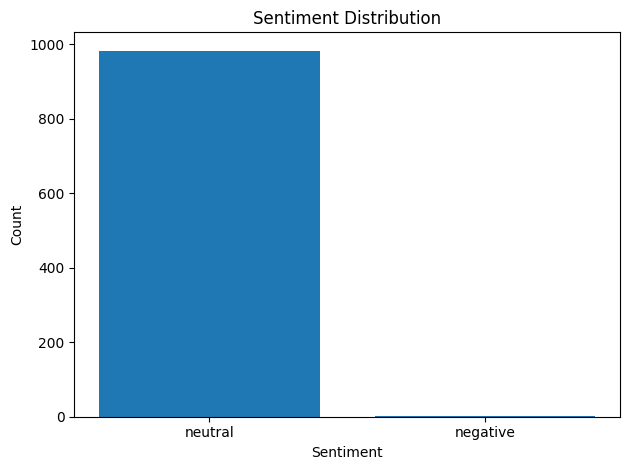

In [69]:
import matplotlib.pyplot as plt

counts = df["label_bert"].value_counts()

plt.figure()
plt.bar(counts.index, counts.values)
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Distribution")
plt.tight_layout()
plt.show()